In [2]:
!pip install -q transformers datasets accelerate evaluate torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [3]:
import torch
from torchvision.datasets import CIFAR10
from torchvision import transforms

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer
)

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [03:38<00:00, 780kB/s]


In [5]:
from torch.utils.data import Subset

train_dataset = Subset(
    train_dataset,
    range(500)
)

test_dataset = Subset(
    test_dataset,
    range(100)
)

In [6]:
model_name = "google/vit-base-patch16-224"

image_processor = AutoImageProcessor.from_pretrained(
    model_name
)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=10,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [7]:
def collate_fn(batch):

    pixel_values = torch.stack(
        [item[0] for item in batch]
    )

    labels = torch.tensor(
        [item[1] for item in batch]
    )

    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

In [8]:
training_args = TrainingArguments(
    output_dir="./vit-cifar10",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="no",
    logging_steps=10
)

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=collate_fn
)

In [10]:
trainer.train()

Step,Training Loss
10,2.232150
20,1.853144
30,1.544024
40,1.357032
50,1.169387
60,0.963532


TrainOutput(global_step=63, training_loss=1.49455231711978, metrics={'train_runtime': 17.4105, 'train_samples_per_second': 28.718, 'train_steps_per_second': 3.619, 'total_flos': 3.8748772952064e+16, 'train_loss': 1.49455231711978, 'epoch': 1.0})

In [11]:
trainer.evaluate()

{'eval_loss': 1.1059579849243164,
 'eval_runtime': 1.153,
 'eval_samples_per_second': 86.73,
 'eval_steps_per_second': 11.275,
 'epoch': 1.0}

In [13]:
sample_image, label = test_dataset[0]

inputs = {
    "pixel_values": sample_image.unsqueeze(0).to(model.device)
}

with torch.no_grad():
    outputs = model(**inputs)

pred = outputs.logits.argmax(-1)

print("Predicted Class:", pred.item())
print("Actual Class:", label)

Predicted Class: 3
Actual Class: 3


In [14]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Predicted:", classes[pred.item()])
print("Actual:", classes[label])

Predicted: cat
Actual: cat


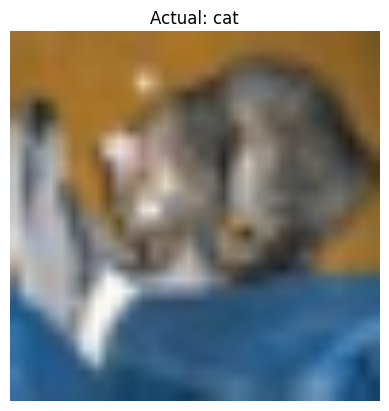

In [15]:
import matplotlib.pyplot as plt

image, label = test_dataset[0]

plt.imshow(image.permute(1,2,0))
plt.title(f"Actual: {classes[label]}")
plt.axis("off")
plt.show()